In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, zero_one_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dataset/bank-full.csv',sep=';')
df_numerica = df[['age','balance','duration','y']]

In [3]:
mapeamento = {'yes':1,'no':0}
df_numerica = df_numerica.replace(mapeamento)

Y = df_numerica['y']
X = df_numerica.drop(columns=['y'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

A acurácia do modelo Random Forest foi de 87.89%


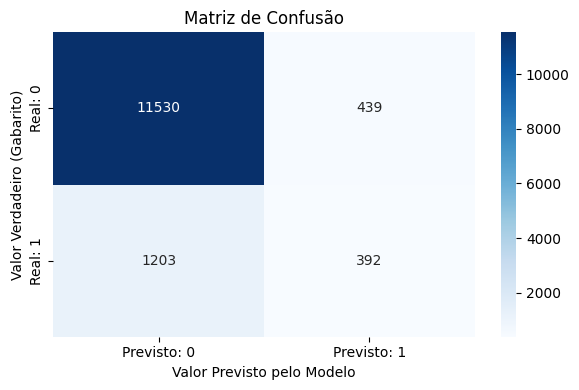

In [ ]:
modelo = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)

modelo.fit(X_train,y_train)

Y_predict = modelo.predict(X_test)

accuracy = accuracy_score(y_test,Y_predict)
print(f'A acurácia do modelo Random Forest foi de {accuracy*100:.2f}%')

matriz_c = confusion_matrix(y_test,Y_predict)
#print(matriz_c)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()